In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Improve the appearance of graphs
sns.set_theme(style="whitegrid")

# Set the project folder
project_folder = Path("D:/user/Documents/New folder")

# Load the dataset
df = pd.read_csv(project_folder / "depression_data.csv")

# Create folders for saving results
plot_folder = project_folder / "results" / "eda_visualizations"
output_folder = project_folder / "results" / "outputs"

plot_folder.mkdir(parents=True, exist_ok=True)
output_folder.mkdir(parents=True, exist_ok=True)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [2]:
# Display column names and data types
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values
})

display(column_summary)

,Column,Data Type,Unique Values
0,Name,str,196851
1,Age,int64,63
2,Marital Status,str,4
3,Education Level,str,5
4,Number of Children,int64,5
5,Smoking Status,str,3
6,Physical Activity Level,str,3
7,Employment Status,str,2
8,Income,float64,405282
9,Alcohol Consumption,str,3


In [3]:
# Count the total records and distinct names
total_records = len(df)
unique_names = df["Name"].nunique()
missing_names = df["Name"].isna().sum()

print("Total records:", total_records)
print("Distinct names:", unique_names)
print("Missing names:", missing_names)

# Explain the feature selection decision
print("\nFeature selection decision:")
print("Remove Name because personal names are not justified")
print("input features for the selected prediction task.")
print("Encoding names would introduce many categories.")

Total records: 413768
Distinct names: 196851
Missing names: 0

Feature selection decision:
Remove Name because personal names are not justified
input features for the selected prediction task.
Encoding names would introduce many categories.


In [4]:
# Store the original dataset dimensions
rows_before = df.shape[0]
columns_before = df.shape[1]

# Remove the Name column without changing the original dataset
df_selected = df.drop(columns=["Name"]).copy()

# Store the new dataset dimensions
rows_after = df_selected.shape[0]
columns_after = df_selected.shape[1]

print("Removed column: Name")
print("Columns before feature selection:", columns_before)
print("Columns after feature selection:", columns_after)
print("Rows before feature selection:", rows_before)
print("Rows after feature selection:", rows_after)

df_selected.head()

Removed column: Name
Columns before feature selection: 16
Columns after feature selection: 15
Rows before feature selection: 413768
Rows after feature selection: 413768


,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [5]:
# Create a comparison of dataset dimensions
feature_comparison = pd.DataFrame({
    "Measurement": ["Rows", "Columns"],
    "Before Selection": [rows_before, columns_before],
    "After Selection": [rows_after, columns_after]
})

display(feature_comparison)

# Display the remaining columns
print("\nRemaining columns:")
print(df_selected.columns.tolist())

,Measurement,Before Selection,After Selection
0,Rows,413768,413768
1,Columns,16,15



Remaining columns:
['Age', 'Marital Status', 'Education Level', 'Number of Children', 'Smoking Status', 'Physical Activity Level', 'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness', 'History of Substance Abuse', 'Family History of Depression', 'Chronic Medical Conditions']


In [6]:
# Set the target column
# Confirm this target with your group
target_column = "History of Mental Illness"

# Separate input features and target
X = df_selected.drop(columns=[target_column]).copy()
y = df_selected[target_column].copy()

print("Target variable:", target_column)
print("Target shape:", y.shape)

Target variable: History of Mental Illness
Target shape: (413768,)


In [7]:
# Set the example target column
target_column = "History of Mental Illness"

# Select the target values
y = df_selected[target_column].copy()

# Keep missing values visible
target_labels = y.astype("string").fillna("(Missing)")

# Calculate category counts and percentages
target_counts = target_labels.value_counts()
target_percentages = (target_counts / len(y)) * 100

# Create the summary table used by the graph
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary.index.name = target_column

display(target_summary.round(2))

,Count,Percentage
History of Mental Illness,,
No,287943,69.59
Yes,125825,30.41


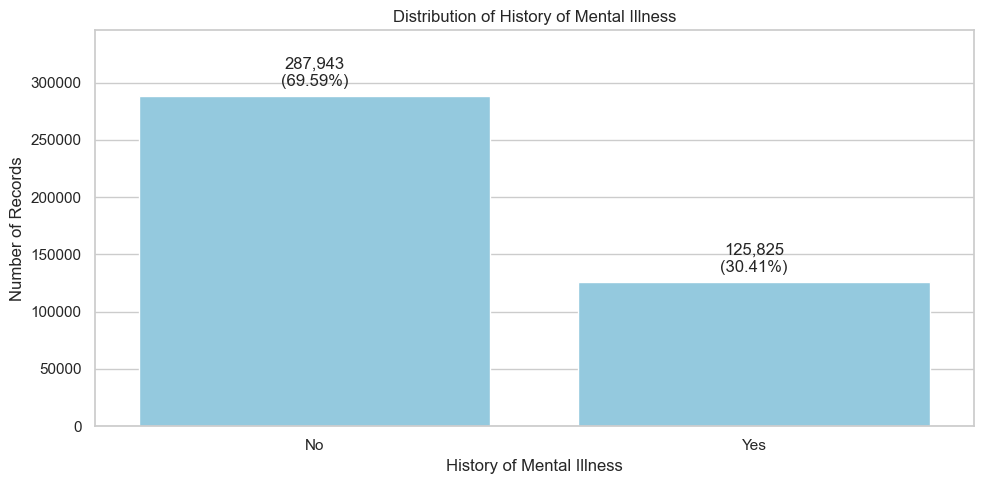

In [8]:
# Create a bar chart of the target categories
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=target_summary.index.astype(str),
    y=target_summary["Count"].to_numpy(),
    color="skyblue"
)

# Display the count and percentage above each bar
for bar, count, percentage in zip(
    ax.patches,
    target_summary["Count"],
    target_summary["Percentage"]
):
    ax.annotate(
        f"{count:,}\n({percentage:.2f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.title("Distribution of " + target_column)
plt.xlabel(target_column)
plt.ylabel("Number of Records")
plt.ylim(0, target_counts.max() * 1.20)
plt.tight_layout()

# Save the visualization
plt.savefig(
    plot_folder / "target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# Identify the most common target category
majority_category = target_counts.idxmax()
majority_count = target_counts.max()
majority_percentage = target_percentages.loc[majority_category]

print("Target variable:", target_column)
print("Most common category:", majority_category)
print("Records in this category:", majority_count)
print(f"Percentage: {majority_percentage:.2f}%")

# Explain the distribution
print("\nGraph interpretation:")

for category in target_counts.index:
    print(
        f"{category}: {target_counts[category]:,} records "
        f"({target_percentages[category]:.2f}%)"
    )

print("\nThe chart shows whether target categories")
print("have similar or different numbers of records.")
print("Removing Name does not change these counts.")

Target variable: History of Mental Illness
Most common category: No
Records in this category: 287943
Percentage: 69.59%

Graph interpretation:
No: 287,943 records (69.59%)
Yes: 125,825 records (30.41%)

The chart shows whether target categories
have similar or different numbers of records.
Removing Name does not change these counts.


In [17]:
# Save the dataset after removing Name
df_selected.to_csv(
    output_folder / "feature_selected_data.csv",
    index=False
)

# Save the selected input feature names
pd.DataFrame({
    "Selected Feature": X.columns
}).to_csv(
    output_folder / "selected_features.csv",
    index=False
)

# Save the target distribution table
target_summary.round(2).to_csv(
    output_folder / "target_distribution.csv"
)

print("Results saved successfully.")
print("Dataset and tables:", output_folder)
print("Visualization:", plot_folder)

Results saved successfully.
Dataset and tables: D:\user\Documents\New folder\results\outputs
Visualization: D:\user\Documents\New folder\results\eda_visualizations
